# Stratified (quiet) resampling

When a beam is down-sampled to fewer macroparticles, *random* resampling adds shot noise. For spectral quantities such as the [bunching factor](bunching.ipynb)

$$ B(\lambda) = \frac{\left|\sum_i w_i e^{i k z_i}\right|}{\sum_i w_i}, \qquad k = \frac{2\pi}{\lambda}, $$

this noise sets a floor of order $1/\sqrt{n}$ that masks the true spectrum at short wavelengths.

`ParticleGroup.stratified_resample(n, key=...)` instead sorts the alive particles along `key`, splits them into `n` equal-count strata, and draws one particle per stratum. This *quiet* loading suppresses the sampling noise, so the down-sampled spectral power density tracks the full beam much further down.

Here we demonstrate this on an idealized Gaussian bunch, whose bunching factor has the closed form $B(\lambda) = e^{-2\pi^2 \sigma_z^2 / \lambda^2}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from beamphysics import ParticleGroup

## An idealized Gaussian bunch

Build a Gaussian bunch with spread in `z` (and a fixed time), 1 nC total charge, with equal particle weights.

In [2]:
rng = np.random.default_rng(0)

n_full = 200_000
sigma_z = 10e-6  # m

data = dict(
    x=rng.normal(0, 100e-6, n_full),
    px=rng.normal(0, 1e3, n_full),
    y=rng.normal(0, 100e-6, n_full),
    py=rng.normal(0, 1e3, n_full),
    z=rng.normal(0, sigma_z, n_full),
    pz=np.full(n_full, 1e9) + rng.normal(0, 1e6, n_full),
    t=np.zeros(n_full),
    status=np.ones(n_full, dtype=int),
    weight=np.full(n_full, 1e-9 / n_full),  # 1 nC, equal weights
    species="electron",
)

P = ParticleGroup(data=data)
P

<ParticleGroup with 200000 particles at 0x10eba6510>

## Down-sample two ways

Reduce the bunch to the same small number of macroparticles using the existing random method and the new stratified method. Both preserve the total charge and return equally weighted particles.

In [ ]:
n_down = 2_000

# Random down-sampling (default). Seed numpy's global RNG for a reproducible figure.
np.random.seed(0)
P_random = P.resample(n_down)

# Stratified (quiet) down-sampling along z.
# Equivalent to: P.resample(n_down, method="stratified", key="z")
P_strat = P.stratified_resample(n_down, key="z")

for label, Q in [("full", P), ("random", P_random), ("stratified", P_strat)]:
    print(f"{label:>11}: n={Q.n_particle:>7}, charge={Q.charge:.4e} C")

## Compare the bunching spectra

Sweep the bunching factor over wavelength for each beam, and overlay the analytic Gaussian form factor. The dashed line marks the $1/\sqrt{n}$ random-sampling noise floor.

In [4]:
wavelengths = np.geomspace(2e-6, 80e-6, 250)

def spectrum(pg):
    return np.array([np.abs(pg.bunching(w)) for w in wavelengths])

b_full = spectrum(P)
b_random = spectrum(P_random)
b_strat = spectrum(P_strat)

# Analytic Gaussian form factor
b_theory = np.exp(-2 * np.pi**2 * sigma_z**2 / wavelengths**2)

noise_floor = 1 / np.sqrt(n_down)

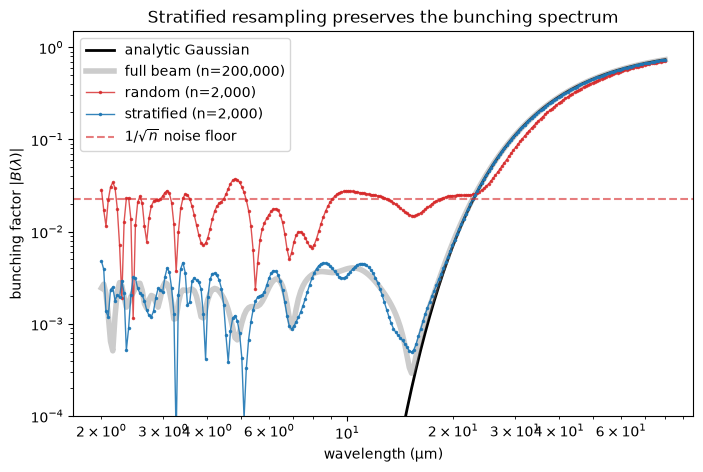

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
wl_um = wavelengths * 1e6

ax.plot(wl_um, b_theory, "k-", lw=2, label="analytic Gaussian")
ax.plot(wl_um, b_full, color="0.5", lw=4, alpha=0.4, label=f"full beam (n={n_full:,})")
ax.plot(wl_um, b_random, "C3.-", ms=3, lw=1, alpha=0.8, label=f"random (n={n_down:,})")
ax.plot(wl_um, b_strat, "C0.-", ms=3, lw=1, alpha=0.9, label=f"stratified (n={n_down:,})")
ax.axhline(noise_floor, ls="--", color="C3", alpha=0.6, label=r"$1/\sqrt{n}$ noise floor")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-4, 1.5)
ax.set_xlabel("wavelength (µm)")
ax.set_ylabel("bunching factor $|B(\\lambda)|$")
ax.set_title("Stratified resampling preserves the bunching spectrum")
ax.legend()
plt.show()

The stratified curve tracks the true Gaussian form factor well below the random method's $1/\sqrt{n}$ noise floor. Random down-sampling saturates at that floor and loses all spectral information at short wavelengths, while stratified (quiet) sampling retains it.

We can quantify this as the shortest wavelength at which each method still tracks the analytic spectrum within a factor of two:

In [6]:
def shortest_tracked_wavelength(b_measured, tol=2.0):
    # Wavelengths are ascending->descending bunching; find shortest wl still within tol of theory
    ok = (b_measured < tol * b_theory) & (b_measured > b_theory / tol)
    return wavelengths[ok].min() if ok.any() else np.nan

for label, b in [("random", b_random), ("stratified", b_strat)]:
    print(f"{label:>11}: tracks down to {shortest_tracked_wavelength(b) * 1e6:.1f} \u00b5m")

     random: tracks down to 21.4 µm
 stratified: tracks down to 15.7 µm
